In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import string
import matplotlib.patches as mpatches
from datetime import datetime
from shapely.geometry import LineString, MultiLineString
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

In [2]:
def plot_distribution(host, ax, xlim, ylim, hide_spines):
    # === 1. 读取地图数据（省级和县级） ===
    geo_prov = gpd.read_file(Path("../0_map/中国_省_202509_GS(2024)0650.geojson"))
    geo_county = gpd.read_file(Path("../0_map/中国_县_202509_GS(2024)0650.geojson"))
    geo_county['gb'] = geo_county['gb'].astype(str)

    # 绘制省级边界
    geo_prov.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.0, zorder=2)

    # === 2. 读取预测分布并 merge ===
    pred_file = Path(f"output/4_predict/host/prob/{host}_statistic.xlsx")
    pred = pd.read_excel(pred_file)
    pred['gb'] = pred['gb'].astype(str)
    gdf_pred = geo_county.merge(pred, on='gb', how='left')

    # 绘制预测分布
    colors=['white', 'lightgoldenrodyellow', 'khaki',  'darkkhaki', 'goldenrod','saddlebrown']
    # base_color = 'goldenrod'
    # alphas = [0, 0.1, 0.2, 0.3, 0.4, 1.0]
    # colors_with_alpha = [(*mcolors.to_rgb(base_color), a) for a in alphas]
    pred_lbd=[0, 0.1, 0.2, 0.3, 0.4, 0.5]
    pred_ubd=[0.1, 0.2, 0.3, 0.4, 0.5, 1.0]
    for i in range(6):
        tmp=gdf_pred[(gdf_pred['mean']>=pred_lbd[i]) & (gdf_pred['mean']<pred_ubd[i])].reset_index(drop=True)
        if tmp.shape[0]>0:
            tmp.plot(ax=ax, color=colors[i], alpha=1.0)

    # === 3. 读取观察数据并 merge ===
    data_file = Path("../1_clean/data_merge_all_20260110.xlsx")
    data = pd.read_excel(data_file)
    data = data[~(data['host_species'].isna() & data['standard virus name'].isna())].reset_index(drop=True) #key
    data['gb'] = data['gb'].astype(str)
    print(data.shape[0])

    # pivot 后提取指定 host 的 presence
    data_pivot_species = (
        data.assign(presence=1)
        .pivot_table(index="gb", columns="host_species", values="presence", aggfunc="max", fill_value=0)
        .reset_index()
    )

    data_pivot_genus = (
        data.assign(presence=1)
        .pivot_table(index="gb", columns="host_genus", values="presence", aggfunc="max", fill_value=0)
        .reset_index()
    )

    if host=='Rattus' or host=='Crocidura':
        case_control_df = data_pivot_genus[['gb', host]].rename(columns={host: 'status'})
    else:
        case_control_df = data_pivot_species[['gb', host]].rename(columns={host: 'status'})
    gdf_obs = geo_county.merge(case_control_df, on='gb', how='left')
    gdf_obs = gdf_obs[gdf_obs['status'] == 1].reset_index(drop=True)

    # =========================
    # 手动添加 presence 底纹（统一经度网格）
    # =========================

    spacing = 0.5  # 经度间隔（度，适用于 EPSG:4326 / 4490）

    # ---- 全局统一的经度竖线网格 ----
    global_min_x, _, global_max_x, _ = gdf_obs.total_bounds

    x_grid = np.arange(
        np.floor(global_min_x / spacing) * spacing,
        np.ceil(global_max_x / spacing) * spacing + spacing,
        spacing
    )

    # ---- 对每个 presence=1 的县区裁剪并绘制 ----
    for geom in gdf_obs.geometry:
        min_x, min_y, max_x, max_y = geom.bounds

        # 只取落在该县 bbox 内的全局竖线
        x_values = x_grid[(x_grid >= min_x) & (x_grid <= max_x)]

        for x in x_values:
            vertical_line = LineString([(x, min_y), (x, max_y)])

            if not vertical_line.intersects(geom):
                continue

            inter = vertical_line.intersection(geom)

            if inter.is_empty:
                continue

            if isinstance(inter, LineString):
                ax.plot(
                    *inter.xy,
                    color='black',
                    linewidth=0.5,
                    zorder=1
                )

            elif isinstance(inter, MultiLineString):
                for seg in inter.geoms:
                    ax.plot(
                        *seg.xy,
                        color='black',
                        linewidth=0.5,
                        zorder=1
                    )


    # === 5. 设置坐标和图形参数 ===
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    if hide_spines:
        for spine in ax.spines.values():
            spine.set_visible(False)

    # province_labels = {
    #     'Xinjiang': (84, 41), 'Xizang': (88, 30), 'Qinghai': (93, 35), 'Gansu': (100, 38),
    #     'Sichuan': (100, 30), 'Yunnan': (99, 24), 'Guangxi': (106, 22.5), 'Hainan': (107, 19),
    #     'Guizhou': (104.5, 26.5), 'Guangdong': (110, 23.5), 'Chongqing': (103, 29),
    #     'Hunan': (109.5, 27), 'Hubei': (111, 30.5), 'Jiangxi': (114, 28), 'Fujian': (117, 26),
    #     'Taiwan': (119, 23), 'Zhejiang': (119, 29), 'Shanghai': (121, 31), 'Anhui': (115, 31.5),
    #     'Henan': (111, 33), 'Jiangsu': (119, 32.5), 'Shandong': (115, 36), 'Shanxi': (110, 37),
    #     'Shaanxi': (106, 34), 'Ningxia': (104, 37), 'Hebei': (113.5, 37.5), 'Tianjin': (117, 38.5),
    #     'Beijing': (115, 40.0), 'Inner Mongolia': (108, 43), 'Liaoning': (120, 41), 'Jilin': (126, 43),
    #     'Heilongjiang': (125, 46), 'Hongkong': (114, 22), 'Macao': (112, 21)
    # }
    # if xlim==(72.5, 135.5):
    #     if province_labels:
    #         for name, (x, y) in province_labels.items():
    #             ax.text(x, y, name, color='grey', fontsize=10, alpha=0.5)

def plot_species_names(ax, host):
    ax.text(
        0.5, 0.5,
        r'$\it{{{}}}$'.format(host.replace(" ", r"\ ")),
        transform=ax.transAxes,  # 以轴坐标为参考
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='left'
    )

    # 隐藏坐标轴
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

47196
47196
47196
47196
47196
47196
47196
47196
47196
47196


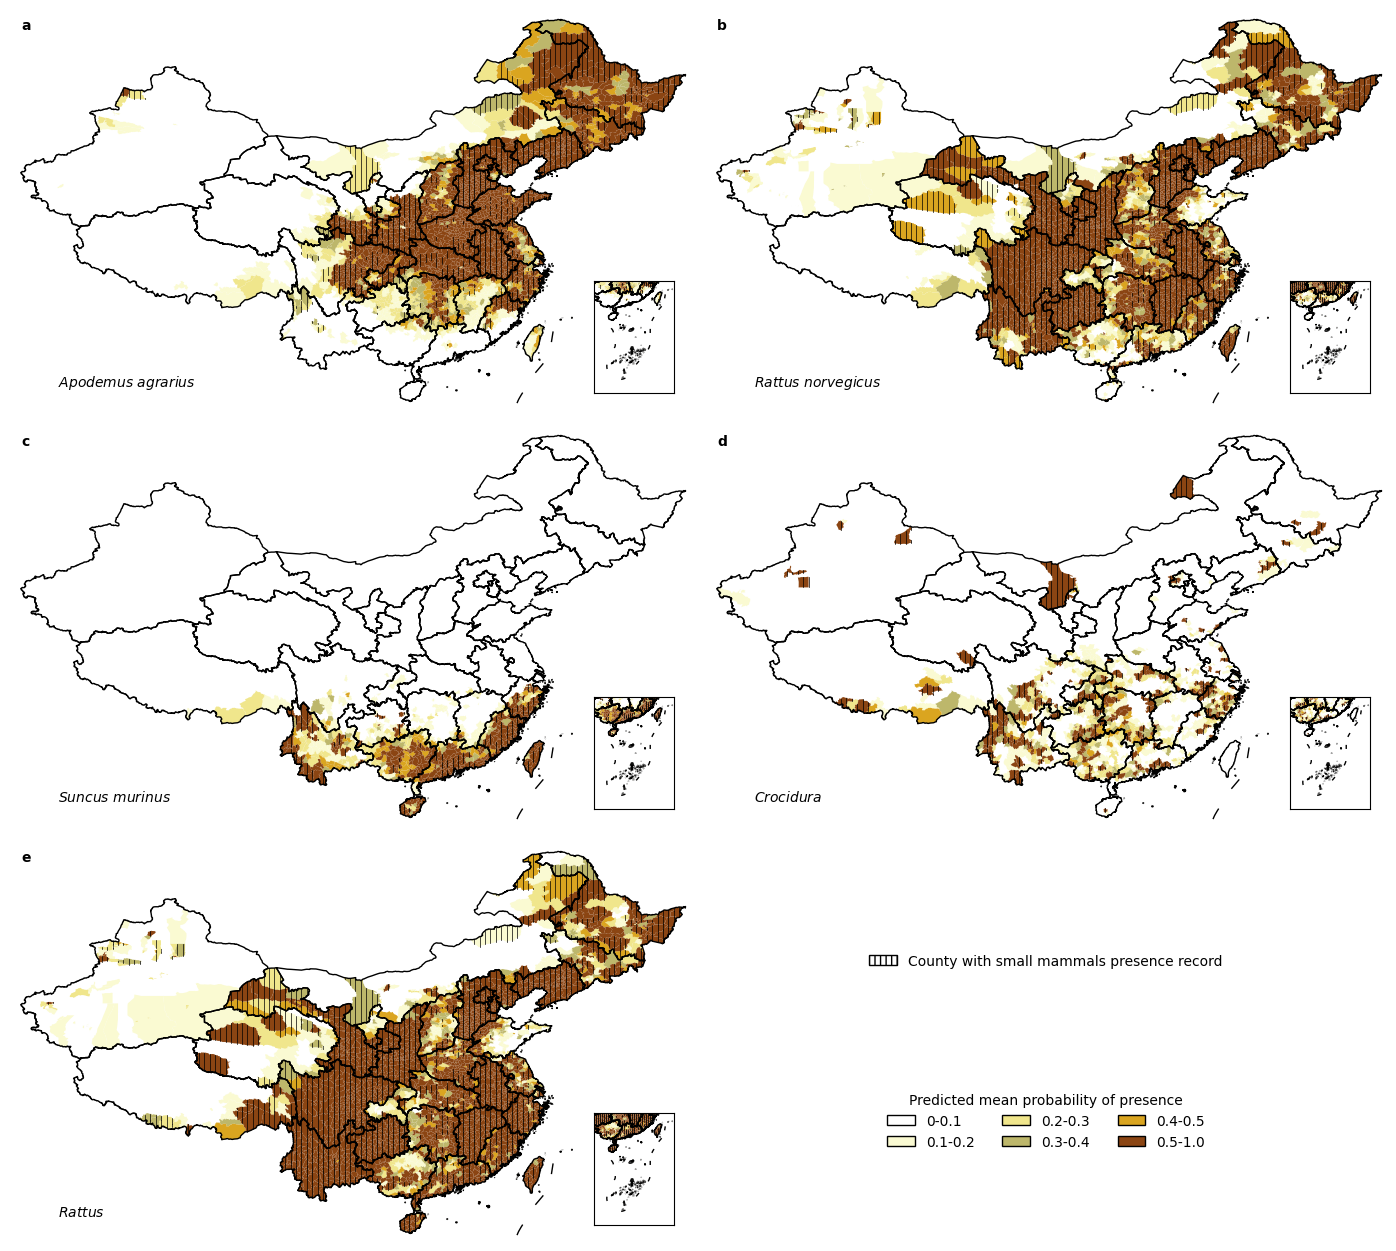

In [3]:
fig = plt.figure(figsize=(8, 8))

letters = list(string.ascii_lowercase)
scale = 1

hosts=['Apodemus agrarius', 'Rattus norvegicus', 'Suncus murinus', 'Crocidura', 'Rattus']

for i in range(len(hosts)):
    idx=int(i/2)
    idy=int(i%2)

    # ============================================================
    #                       Main map
    # ============================================================
    ax_main = fig.add_axes([(0.85 * scale + 0.02) * idy, 1.0 - (0.5 * scale + 0.02) * idx, 0.85 * scale, 0.5 * scale])
    plot_distribution(hosts[i], ax_main, (72.5, 135.5), (17.5, 54.5), hide_spines=True)

    # ============================================================
    #                       Insert map
    # ============================================================
    ax_inset = fig.add_axes([-0.14+ (0.02 + 0.85 * scale) * (1+idy), 1.0 - (0.5 * scale + 0.02) * idx + 0.02, 0.1 * scale, 0.14 * scale])
    plot_distribution(hosts[i], ax_inset,  (105, 125), (0, 28), hide_spines=False)

    # ============================================================
    #                       Virus name
    # ============================================================
    ax_text = fig.add_axes([(0.85 * scale + 0.02) * idy + 0.01, 1.0 - (0.5 * scale + 0.02) * idx + 0.02, 0.1, 0.05])
    plot_species_names(ax_text, hosts[i])

    # ============================================================
    #                       Figure index
    # ============================================================
    fig.text((0.85 * scale + 0.02) * idy + 0.02, 1.0 - (0.5 * scale + 0.02) * idx + 0.5 * scale - 0.02, letters[i], ha='center', va='center', fontsize=10, weight='bold')

# ============================================================
#                      Legend
# ============================================================
ax6 = fig.add_axes([(0.85 * scale + 0.02), 1.0 - (0.5 * scale + 0.02) * 2 + 0.3, 0.85 * scale, 0.1], zorder=2)
ax6.set_xticks([])
ax6.set_yticks([])
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.spines['bottom'].set_visible(False)
ax6.spines['left'].set_visible(False)
hatch_patch = mpatches.Patch(facecolor='none',hatch='|||', edgecolor='black', label='County with small mammals presence record')
legend1=ax6.legend(handles=[hatch_patch], frameon=False, fontsize=10, loc='center')

ax7 = fig.add_axes([(0.85 * scale + 0.02), 1.0 - (0.5 * scale + 0.02) * 2, 0.85 * scale, 0.3], zorder=1)
ax7.set_xticks([])
ax7.set_yticks([])
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)
ax7.spines['bottom'].set_visible(False)
ax7.spines['left'].set_visible(False)
patches1 = [mpatches.Patch(facecolor=color, label=label, edgecolor='black') for color, label in zip(['white', 'lightgoldenrodyellow', 'khaki',  'darkkhaki', 'goldenrod','saddlebrown'], ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', '0.5-1.0'])]
legend1=ax7.legend(handles=patches1, loc='center',  frameon=False, fontsize=10, ncol=3, title='Predicted mean probability of presence', title_fontsize=10)


date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(f'figure/Extended Data Figure2_{date_str}.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()